In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
colors_data = {
    "Red": {"freq": 4.3, "hex": "#FF0000"},
    "Orange": {"freq": 5.0, "hex": "#FFA500"},
    "Yellow": {"freq": 5.2, "hex": "#FFD700"},
    "Green": {"freq": 5.65, "hex": "#008000"},
    "Blue": {"freq": 6.3, "hex": "#0000FF"},
    "Indigo": {"freq": 6.7, "hex": "#4B0082"},
    "Violet": {"freq": 7.5, "hex": "#EE82EE"},
}

In [3]:
# Signal Parameters (Module 2: Sinusoid fundamentals)
A = 1.0  # Peak Amplitude (V or arbitrary unit)
phase = 0.0  # Phase angle (phi) in radians
fs = 1000  # Sampling frequency (samples per second)
t = np.linspace(0, 1.0, fs, endpoint=False)  # Time domain: 1 second

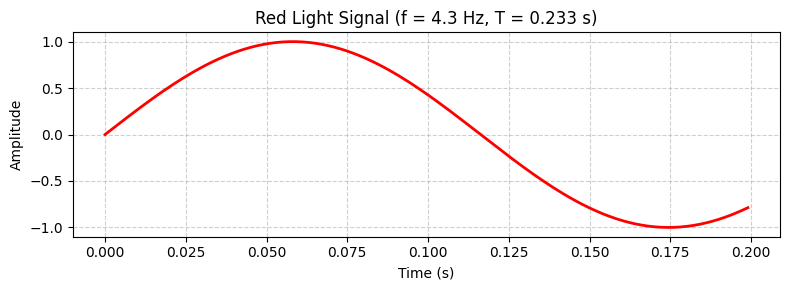

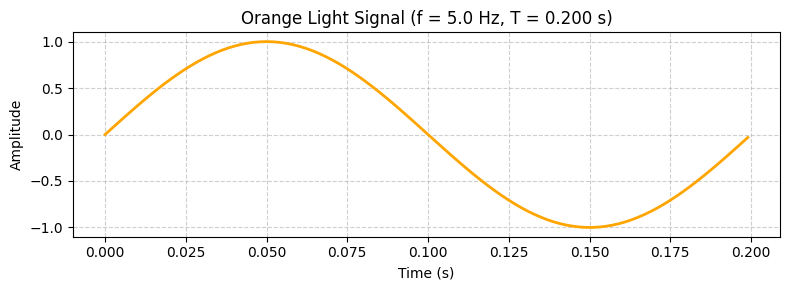

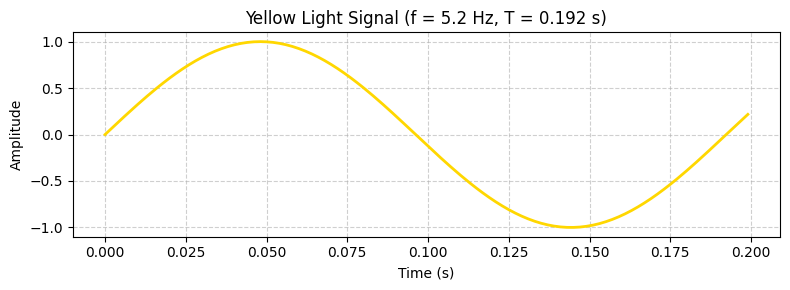

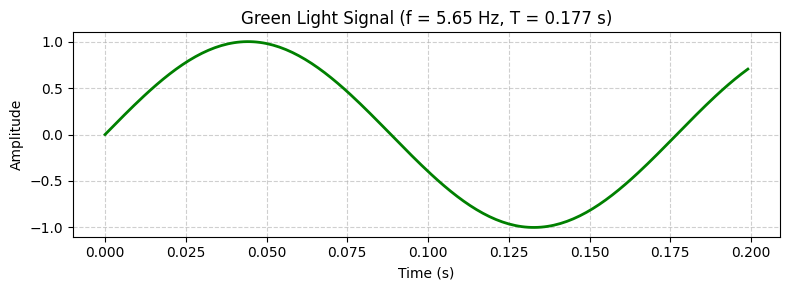

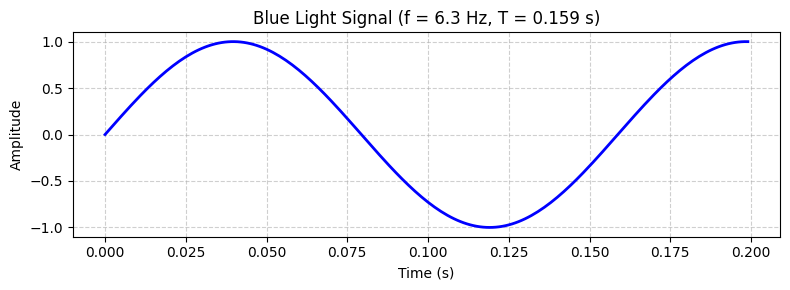

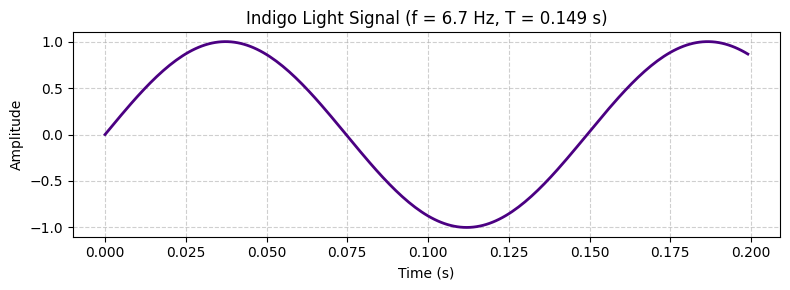

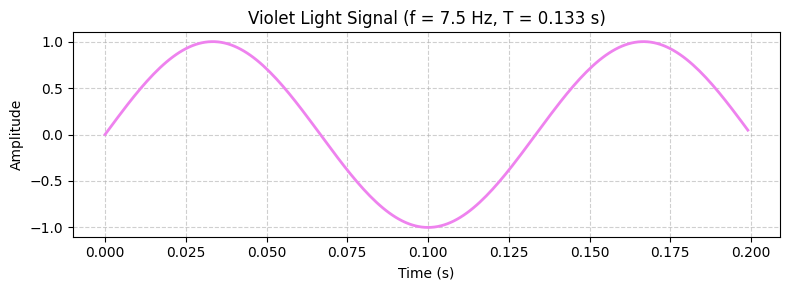

In [4]:
# -------------------------------------------------------------
# 2. INDIVIDUAL COLOR SIGNALS (SECTIONS 1 TO 7)
# Run per color or iterate to export images
# -------------------------------------------------------------
signals = {}
for name, spec in colors_data.items():
    f = spec["freq"]
    T = 1.0 / f  # Period T = 1/f

    # Sinusoid equation: s(t) = A * sin(2 * pi * f * t + phase)
    s = A * np.sin(2 * np.pi * f * t + phase)
    signals[name] = s

    plt.figure(figsize=(8, 3))
    plt.plot(t[:200], s[:200], color=spec["hex"], linewidth=2)  # Zoomed to 0.2s
    plt.title(f"{name} Light Signal (f = {f} Hz, T = {T:.3f} s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

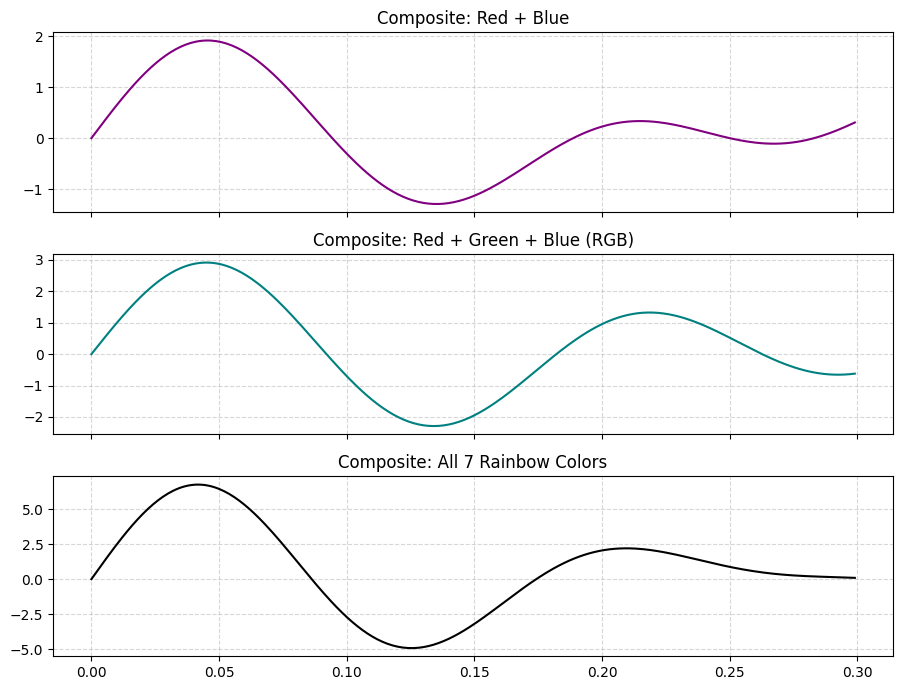

In [5]:
# -------------------------------------------------------------
# 3. COMPOSITE SIGNALS (SECTION 8)
# Combining waves: 2-color, 3-color, and all 7 colors
# -------------------------------------------------------------
comp_2 = signals["Red"] + signals["Blue"]
comp_3 = signals["Red"] + signals["Green"] + signals["Blue"]
comp_all = sum(signals.values())

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t[:300], comp_2[:300], color="purple")
axes[0].set_title("Composite: Red + Blue")
axes[1].plot(t[:300], comp_3[:300], color="teal")
axes[1].set_title("Composite: Red + Green + Blue (RGB)")
axes[2].plot(t[:300], comp_all[:300], color="black")
axes[2].set_title("Composite: All 7 Rainbow Colors")
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

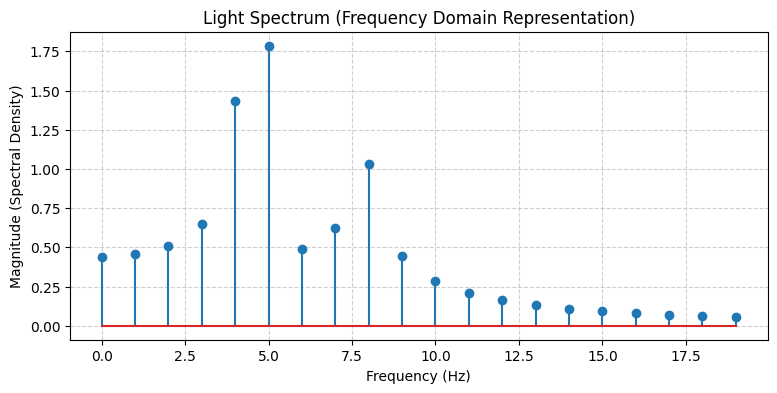

In [6]:
# -------------------------------------------------------------
# 4. FREQUENCY DOMAIN SPECTRUM (SECTION 9)
# Fast Fourier Transform (FFT) of the All-Colors Composite
# -------------------------------------------------------------
fft_vals = np.fft.rfft(comp_all)
fft_freqs = np.fft.rfftfreq(len(t), 1 / fs)
magnitudes = np.abs(fft_vals) * (2 / len(t))

plt.figure(figsize=(9, 4))
plt.stem(fft_freqs[:20], magnitudes[:20])  # Plot discrete spectral lines
plt.title("Light Spectrum (Frequency Domain Representation)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (Spectral Density)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()